In [1]:
import pandas as pd
import numpy as np
import os
import glob
import statsmodels.api as sm


In [2]:
# path to folder
folder_path = "./Task2Data/*"

# get list of csv files
files = glob.glob(folder_path)

structural = {}
functional = {}

for file in files:

    name = os.path.basename(file)
    subject = name.split("_")[0]   # extracts subject ID

    mat = pd.read_csv(file, comment='#', header=None).values

    if "WFA" in name:
        structural[subject] = mat

    elif "rsfMRI" in name:
        functional[subject] = mat

print(len(structural), len(functional))

19 19


In [3]:
def indirect_connectivity(S):

    n = S.shape[0]
    T = np.zeros_like(S)

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            vals = []

            for k in range(n):

                if S[i,k] > 0 and S[k,j] > 0:
                    vals.append(min(S[i,k], S[k,j]))

            if vals:
                T[i,j] = max(vals)

    return T

In [4]:
T_matrices = {}

for subject in structural:

    S = structural[subject]
    T = indirect_connectivity(S)

    T_matrices[subject] = T

T_matrices


{'32': array([[0.        , 0.42255735, 0.40971658, ..., 0.        , 0.        ,
         0.42255735],
        [0.42255735, 0.        , 0.49604311, ..., 0.32162235, 0.46948489,
         0.45943316],
        [0.40971658, 0.49604311, 0.        , ..., 0.34516057, 0.46948489,
         0.43447875],
        ...,
        [0.        , 0.32162235, 0.34516057, ..., 0.        , 0.34516057,
         0.34516057],
        [0.        , 0.46948489, 0.46948489, ..., 0.34516057, 0.        ,
         0.42188022],
        [0.42255735, 0.45943316, 0.43447875, ..., 0.34516057, 0.42188022,
         0.        ]]),
 '33': array([[0.        , 0.41149768, 0.43011361, ..., 0.        , 0.        ,
         0.43516083],
        [0.41149768, 0.        , 0.48380023, ..., 0.28125498, 0.49564331,
         0.44916189],
        [0.43011361, 0.48380023, 0.        , ..., 0.28125498, 0.48380023,
         0.48352925],
        ...,
        [0.        , 0.28125498, 0.28125498, ..., 0.        , 0.28125498,
         0.28125498],


In [5]:
subjects = list(structural.keys())
# Get the number of regions from one of the structural matrices
num_regions = structural[subjects[0]].shape[0]

## Refit All Models with AIC/BIC


In [6]:
def get_features(structural_data, indirect_structural_data, subjects, region_i, region_j, include_s, include_t, include_s2, include_t2):
  exog = []
  if include_s:
    s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij)
  if include_t:
    t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij)
  if include_s2:
    if not include_s:
      s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij**2)
  if include_t2:
    if not include_t:
      t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij**2)
  return exog


def fit_generalized_model(functional_data, structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2):
    """
    Fits a generalized linear model for functional connectivity and returns coefficients, AIC, and BIC.

    Args:
        functional_data (dict): Dictionary of functional connectivity matrices per subject.
        structural_data (dict): Dictionary of structural connectivity matrices per subject.
        indirect_structural_data (dict): Dictionary of indirect structural connectivity
                                        matrices (T_matrices) per subject.
        subject_list (list): List of subject IDs.
        region_i (int): First brain region index.
        region_j (int): Second brain region index.
        include_s (bool): Whether to include direct structural connectivity (s_ij).
        include_t (bool): Whether to include indirect structural connectivity (t_ij).
        include_s2 (bool): Whether to include squared direct structural connectivity (s_ij^2).
        include_t2 (bool): Whether to include squared indirect structural connectivity (t_ij^2).

    Returns:
        dict or None: A map, containing the parameters, aic and bic if
                               the model is fitted successfully, otherwise None.
    """

    f_ij = np.array([functional_data[s][region_i, region_j] for s in subject_list])

    exog_vars = get_features(structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2)

    if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
        return None

    X = np.column_stack(exog_vars)
    X = sm.add_constant(X)

    model = sm.OLS(f_ij, X).fit()

    return model

In [7]:
model1_results = {}
model2_results = {}
model3_results = {}
model4_results = {}
model5_results = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: fij = ̑̑ij + ̒̑ij sij
        res1 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=False, include_t2=False)
        if res1 is not None:
            model1_results[(i, j)] = res1

        # Model 2: fij = ̑̑ij + ̒̑ij sij + ̓ij sij^2
        res2 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=False, include_s2=True, include_t2=False)
        if res2 is not None:
            model2_results[(i, j)] = res2

        # Model 3: fij = ̑̑ij + ̒̑ij tij
        res3 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=False)

        if res3 is not None:
            model3_results[(i, j)] = res3

        # Model 4: fij = ̑̑ij + ̒̑ij tij + ̓ij tij^2
        res4 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=False, include_t=True, include_s2=False, include_t2=True)
        if res4 is not None:
            model4_results[(i, j)] = res4

        # Model 5: fij = ̑̑ij + ̒̑ij sij + ̓ij tij
        res5 = fit_generalized_model(functional, structural, T_matrices, subjects, i, j,
                                     include_s=True, include_t=True, include_s2=False, include_t2=False)
        if res5 is not None:
            model5_results[(i, j)] = res5

print(f'Refitted models for {num_regions} regions. Example entry (0,2) Model 1 AIC: {model1_results[(0,2)].aic}')

Refitted models for 68 regions. Example entry (0,2) Model 1 AIC: -52.19583544402778


## Implement Leave-One-Out Cross-Validation

In [8]:
def perform_loocv(functional_data, structural_data, indirect_structural_data, subject_list, region_i, region_j, include_s, include_t, include_s2, include_t2):
    """
    Evaluates model predictive performance using Leave-One-Out Cross-Validation (LOOCV).
    Returns the total Sum of Squared Errors (SSE) across all subjects.
    """
    total_sse = 0
    num_subjects = len(subject_list)

    for idx in range(num_subjects):
        # Define training and test subjects
        test_subject = subject_list[idx]
        train_subjects = [s for i, s in enumerate(subject_list) if i != idx]

        # Fit model on training set
        model = fit_generalized_model(functional_data, structural_data, indirect_structural_data, train_subjects, region_i, region_j, include_s, include_t, include_s2, include_t2)
        if model is None:
            continue

        # Prepare test data
        y_test = functional_data[test_subject][region_i, region_j]
        X_test_raw = get_features(structural_data, indirect_structural_data,[test_subject],region_i, region_j, include_s, include_t, include_s2, include_t2)

        if X_test_raw is not None:
          X_test_raw = np.column_stack(X_test_raw)
        X_test = sm.add_constant(X_test_raw, has_constant='add')

        # Predict and calculate squared error
        prediction = model.predict(X_test)[0]
        squared_error = (y_test - prediction)**2
        total_sse += squared_error

    return total_sse

## Calculate SSE for All Models

### Subtask:
Iterate through all brain region pairs and compute the total Sum of Squared Errors (SSE) for each of the five models using the perform_loocv function.


**Reasoning**:
I will initialize the SSE dictionaries and iterate through all brain region pairs to compute the LOOCV SSE for all five models using the previously defined perform_loocv function.



In [9]:
sse_model1 = {}
sse_model2 = {}
sse_model3 = {}
sse_model4 = {}
sse_model5 = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: s_ij
        sse1 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=False, include_t2=False)
        if sse1 is not None:
            sse_model1[(i, j)] = sse1

        # Model 2: s_ij + s_ij^2
        sse2 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=True, include_t2=False)
        if sse2 is not None:
            sse_model2[(i, j)] = sse2

        # Model 3: t_ij
        sse3 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=False)
        if sse3 is not None:
            sse_model3[(i, j)] = sse3

        # Model 4: t_ij + t_ij^2
        sse4 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=True)
        if sse4 is not None:
            sse_model4[(i, j)] = sse4

        # Model 5: s_ij + t_ij
        sse5 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=True, include_s2=False, include_t2=False)
        if sse5 is not None:
            sse_model5[(i, j)] = sse5

print(f"LOOCV SSE calculation completed for {num_regions} regions.")

LOOCV SSE calculation completed for 68 regions.


## Plot Model Comparison


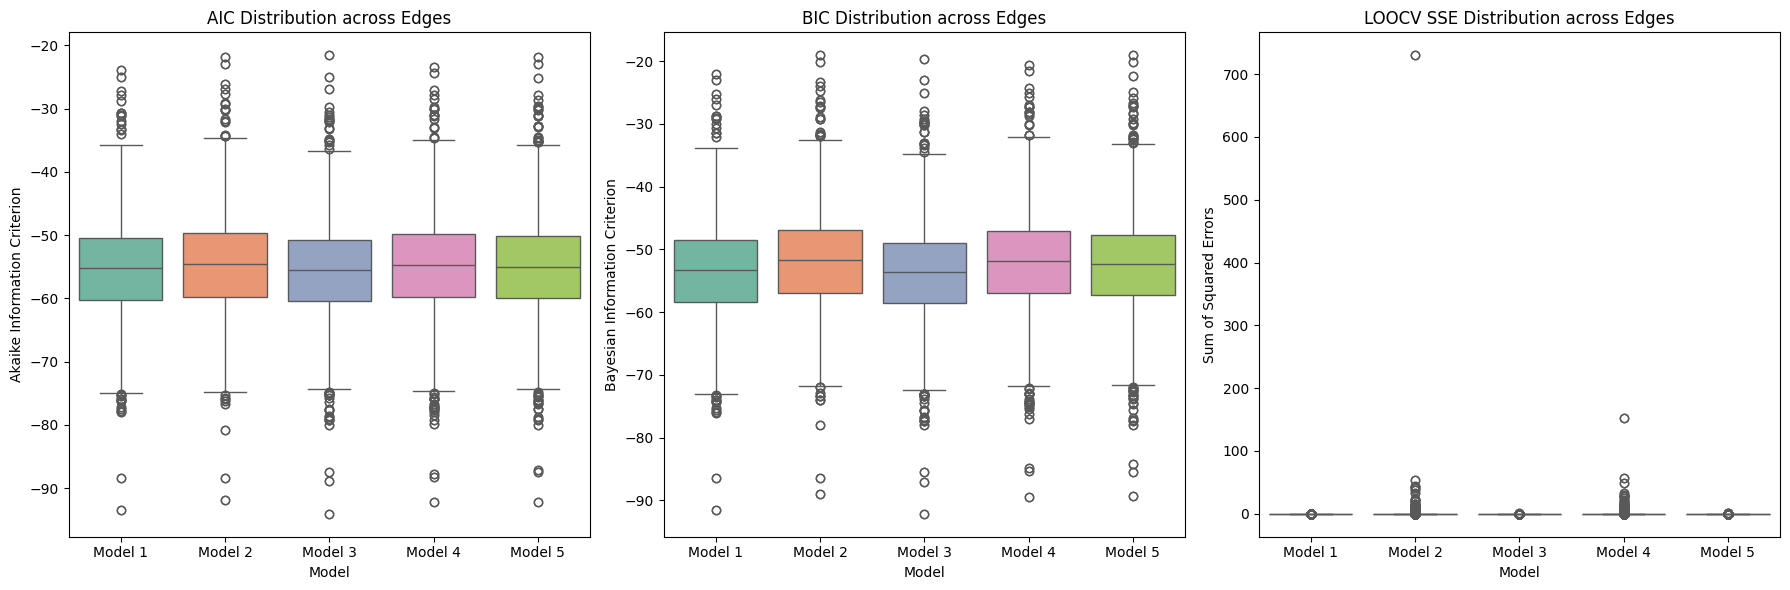

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data lists for AIC, BIC, and SSE
data = []

model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5']
res_dicts = [model1_results, model2_results, model3_results, model4_results, model5_results]
sse_dicts = [sse_model1, sse_model2, sse_model3, sse_model4, sse_model5]

for idx, m_name in enumerate(model_names):
    current_res = res_dicts[idx]
    current_sse = sse_dicts[idx]

    # Get common keys (edges) present in both results and SSE for consistency
    common_keys = set(current_res.keys()) & set(current_sse.keys())

    for key in common_keys:
        data.append({
            'Model': m_name,
            'AIC': current_res[key].aic,
            'BIC': current_res[key].bic,
            'SSE': current_sse[key]
        })

# Create DataFrame
comparison_df = pd.DataFrame(data)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# AIC Box Plot
sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0], palette='Set2', hue='Model', legend=False)
axes[0].set_title('AIC Distribution across Edges')
axes[0].set_ylabel('Akaike Information Criterion')

# BIC Box Plot
sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[1], palette='Set2', hue='Model', legend=False)
axes[1].set_title('BIC Distribution across Edges')
axes[1].set_ylabel('Bayesian Information Criterion')

# SSE Box Plot
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[2], palette='Set2', hue='Model', legend=False)
axes[2].set_title('LOOCV SSE Distribution across Edges')
axes[2].set_ylabel('Sum of Squared Errors')

plt.tight_layout()
plt.show()

Based on the plots, seems that model 3 is the one that performs the best

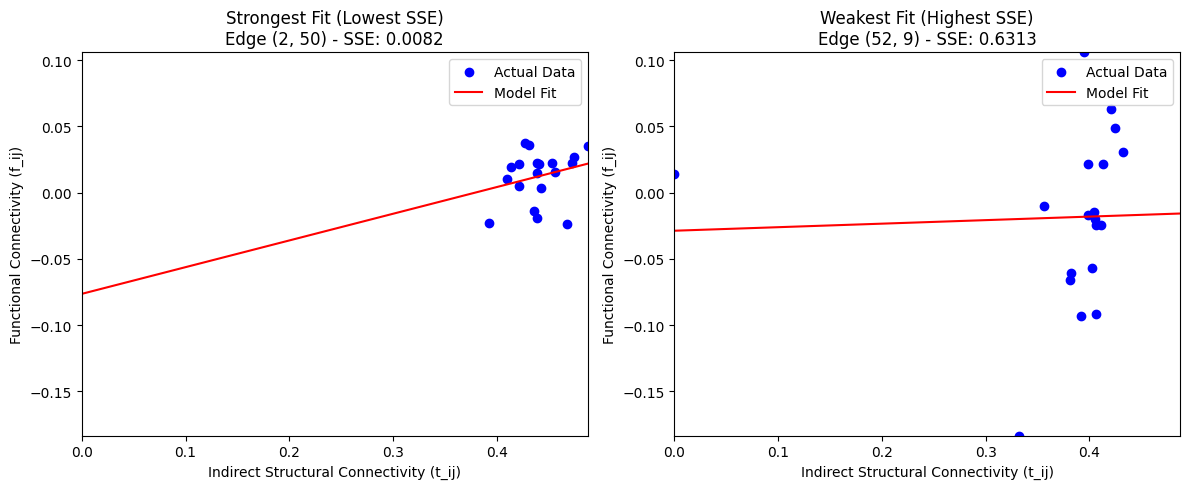

In [11]:
# Get common keys present in both results and SSE for consistency
common_keys = set(model3_results.keys()) & set(sse_model3.keys())

# Filter sse_model3 to only include common keys
filtered_sse_model3 = {k: sse_model3[k] for k in common_keys}

if not filtered_sse_model3:
    print("No common edges found between Model 3 results and SSE. Cannot plot best/worst fit.")
else:
    best_edge = min(filtered_sse_model3, key=filtered_sse_model3.get)
    worst_edge = max(filtered_sse_model3, key=filtered_sse_model3.get)

    edges_to_plot = {
        "Strongest Fit (Lowest SSE)": best_edge,
        "Weakest Fit (Highest SSE)": worst_edge
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    all_t_ij_vals = []
    all_f_ij_vals = []

    for title, edge in edges_to_plot.items():
        i, j = edge
        t_ij_temp = np.array([T_matrices[s][i, j] for s in subjects])
        f_ij_temp = np.array([functional[s][i, j] for s in subjects])
        all_t_ij_vals.extend(t_ij_temp)
        all_f_ij_vals.extend(f_ij_temp)

    # Determine global min/max for consistent scaling
    global_t_ij_min = min(all_t_ij_vals)
    global_t_ij_max = max(all_t_ij_vals)
    global_f_ij_min = min(all_f_ij_vals)
    global_f_ij_max = max(all_f_ij_vals)

    for ax_idx, (title, edge) in enumerate(edges_to_plot.items()):
        ax = axes[ax_idx]
        i, j = edge

        # Use t_ij because model uses the indirect edges
        t_ij = np.array([T_matrices[s][i, j] for s in subjects])
        f_ij = np.array([functional[s][i, j] for s in subjects])

        # Get model result for the current edge
        model_result = model3_results[edge]

        # For Model 3, it's fij = beta0 + beta1 * t_ij. params will have 2 elements.
        intercept = model_result.params[0]
        slope = model_result.params[1]

        # Scatter plot of the raw data
        ax.scatter(t_ij, f_ij, color='blue', label='Actual Data')

        # Plot the regression line
        # We use global min and max of t_ij to draw the line across the full range of the data
        x_vals = np.linspace(global_t_ij_min, global_t_ij_max, 100)
        y_vals = intercept + slope * x_vals
        ax.plot(x_vals, y_vals, color='red', label='Model Fit')

        # Formatting the plot
        ax.set_title(f"{title}\nEdge ({i}, {j}) - SSE: {sse_model3[edge]:.4f}")
        ax.set_xlabel("Indirect Structural Connectivity (t_ij)")
        ax.set_ylabel("Functional Connectivity (f_ij)")
        ax.legend()

        # Set consistent x and y limits
        ax.set_xlim(global_t_ij_min, global_t_ij_max)
        ax.set_ylim(global_f_ij_min, global_f_ij_max)

    plt.tight_layout()
    plt.show()